In [61]:
!curl -O https://raw.githubusercontent.com/gentleman644/foxtrot-thyroid-cancer-prediction/refs/heads/Test/UnitTest.py
# unitTestPath = os.path.join(os.getcwd(), "UnitTest.py")
%run -i "UnitTest.py"

# Imports and load dataset
import importlib
import UnitTest
importlib.reload(UnitTest)

from UnitTest import TestMethods as tm
import pandas as pd
import numpy as np
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Load dataset
dataset = pd.read_csv("https://github.com/gentleman644/foxtrot-thyroid-cancer-prediction/blob/main/thyroid_cancer_risk_data.csv?raw=true",
            header=0, index_col=0)

# Preview dataset 1
print(dataset.head(), "\n") #first 5 rows
print(dataset.tail(), "\n") #last 5 rows
tm.test_load_data(dataset)

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100    745 100    745   0      0   3617      0                              0
100    745 100    745   0      0   3616      0                              0
100    745 100    745   0      0   3604      0                              0


            Age  Gender  Country  Ethnicity Family_History Radiation_Exposure Iodine_Deficiency Smoking Obesity Diabetes  TSH_Level  T3_Level  T4_Level  Nodule_Size Thyroid_Cancer_Risk Diagnosis
Patient_ID                                                                                                                                                                                        
1            66    Male   Russia  Caucasian             No                Yes                No      No      No       No       9.37      1.67      6.16         1.08                 Low    Benign
2            29    Male  Germany   Hispanic             No                Yes                No      No      No       No       1.83      1.73     10.54         4.05                 Low    Benign
3            86    Male  Nigeria  Caucasian             No                 No                No      No      No       No       6.26      2.59     10.57         4.61                 Low    Benign
4            75  Female  

In [62]:
from pandas.api.types import is_numeric_dtype
# Preview data features and figure out problems for data preprocessing
# P1: 11 non-numeric features, which need to be encoded before feeding into ML models
# P2: Class imbalance in the target variable (Diagnosis), which requires oversampling
print(dataset.info(), "\n")
print(dataset.describe(), "\n")

print("Count of each non-numeric feature:")
for col in dataset.columns:
    if (is_numeric_dtype(dataset[col]) == False):
        print(f"{col:<24}({dataset[col].dtype}): {len(dataset[col])}")

print("\nCount of each class in the target variable:")
print(dataset["Diagnosis"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 212691 entries, 1 to 212691
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Age                  212691 non-null  int64  
 1   Gender               212691 non-null  str    
 2   Country              212691 non-null  str    
 3   Ethnicity            212691 non-null  str    
 4   Family_History       212691 non-null  str    
 5   Radiation_Exposure   212691 non-null  str    
 6   Iodine_Deficiency    212691 non-null  str    
 7   Smoking              212691 non-null  str    
 8   Obesity              212691 non-null  str    
 9   Diabetes             212691 non-null  str    
 10  TSH_Level            212691 non-null  float64
 11  T3_Level             212691 non-null  float64
 12  T4_Level             212691 non-null  float64
 13  Nodule_Size          212691 non-null  float64
 14  Thyroid_Cancer_Risk  212691 non-null  str    
 15  Diagnosis            212691 

## Data Preprocessing - Feature Encoding
*Write any notes or observations about the feature encoding process here if you want*

In [63]:
# P1: Encode all non-numeric features (use OrdinalEncoder)
# (Transform all non-numeric features into numeric features, so that we can feed them into ML models)
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder(categories="auto")
dataset_encoded = dataset.copy()
for col in dataset.columns:
    if (is_numeric_dtype(dataset[col]) == False):
        dataset_encoded[col] = ordinal_encoder.fit_transform(dataset[[col]])

print(dataset_encoded.info(), "\n")
print(dataset_encoded.head(), "\n")
print(dataset_encoded.tail(), "\n")

print(f"{'Category':<13} | {'Count':<8} | {'Encoded':<6} | {'Count':<8}")
for col in dataset.columns:
    if (is_numeric_dtype(dataset[col]) == False):
        # Print value counts of original vs encoded, one line each after the other
        print(f"--{col}--")
        original_counts = dataset[col].value_counts().to_dict()
        encoded_counts = dataset_encoded[col].value_counts().to_dict()
        for category in original_counts.keys():
            original_count = original_counts[category]
            encoded_category = dataset_encoded[col].loc[dataset[col].index[dataset[col] == category][0]]
            encoded_count = encoded_counts[encoded_category] if encoded_category is not None else None
            print(f"{str(category):<14}: {original_count:<8} | {str(encoded_category):<8}: {encoded_count:<6}")

dataset = dataset_encoded.copy()
tm.test_ordinal_encoder(dataset)


<class 'pandas.DataFrame'>
RangeIndex: 212691 entries, 1 to 212691
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Age                  212691 non-null  int64  
 1   Gender               212691 non-null  float64
 2   Country              212691 non-null  float64
 3   Ethnicity            212691 non-null  float64
 4   Family_History       212691 non-null  float64
 5   Radiation_Exposure   212691 non-null  float64
 6   Iodine_Deficiency    212691 non-null  float64
 7   Smoking              212691 non-null  float64
 8   Obesity              212691 non-null  float64
 9   Diabetes             212691 non-null  float64
 10  TSH_Level            212691 non-null  float64
 11  T3_Level             212691 non-null  float64
 12  T4_Level             212691 non-null  float64
 13  Nodule_Size          212691 non-null  float64
 14  Thyroid_Cancer_Risk  212691 non-null  float64
 15  Diagnosis            212691 

## Data Preprocessing - Target Variable Class Imbalance
*Write any notes or observations about the target variable class imbalance process here if you want*

In [64]:
# P2: Class imbalance in the target variable (Diagnosis), which requires baalancing
from imblearn.under_sampling import RandomUnderSampler

# 1. Verify columns & class imbalance
print(f"Starting column is '{dataset.columns[0]}'")
print(f"Target variable is '{dataset.columns[15]}'")
print(dataset['Diagnosis'].value_counts())

# 2. Separate features and target variable
feats_X = dataset.iloc[:, :15]
trgt_y = dataset.iloc[:, 15]

# 3. Apply Random Undersampling
rus = RandomUnderSampler(sampling_strategy='majority', random_state=42)
resmpl_X, resmpl_y = rus.fit_resample(feats_X, trgt_y)

# 4. Recombine into a single dataframe
dataset = pd.concat([resmpl_X, resmpl_y], axis=1)

# 5. Verify results
print(resmpl_y.value_counts())
print(dataset.info())
print(dataset.head())

Starting column is 'Age'
Target variable is 'Diagnosis'
Diagnosis
0.0    163196
1.0     49495
Name: count, dtype: int64
Diagnosis
0.0    49495
1.0    49495
Name: count, dtype: int64
<class 'pandas.DataFrame'>
Index: 98990 entries, 124276 to 212691
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  98990 non-null  int64  
 1   Gender               98990 non-null  float64
 2   Country              98990 non-null  float64
 3   Ethnicity            98990 non-null  float64
 4   Family_History       98990 non-null  float64
 5   Radiation_Exposure   98990 non-null  float64
 6   Iodine_Deficiency    98990 non-null  float64
 7   Smoking              98990 non-null  float64
 8   Obesity              98990 non-null  float64
 9   Diabetes             98990 non-null  float64
 10  TSH_Level            98990 non-null  float64
 11  T3_Level             98990 non-null  float64
 12  T4_Level      

## Data visualization - Preview dataset
*Write any notes or observations about the dataset preview here if you want*

Determine any skewness in the dataset, and any problems that need to be handled in data preprocessing.

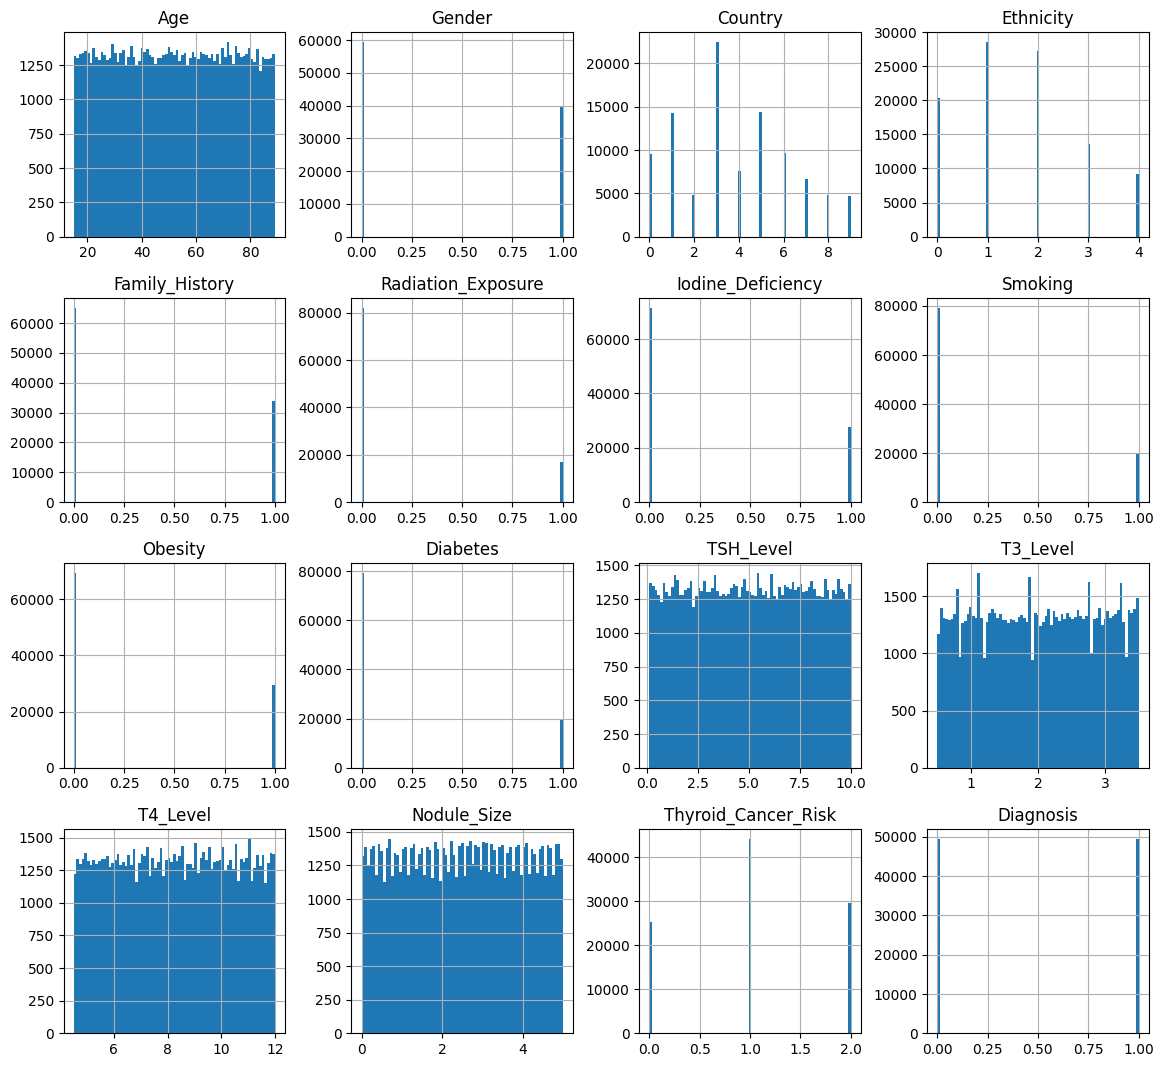

In [65]:
# Part 4: Data graphs

# Cell 7 - histograms:
# 6 histograms are showed for time, temperature, rel.humidity, light, CO2 and humidityRatio.
# All histograms show skewness due to the ammount of data distributed throughout each graph besides the time histogram.
# All other histograms besides occupancy show left skewness - the data data is primarily in the left side of the graph showing a noticeable spike in each graph.
# Occupancy has a bimodial skew, where the data is only on the left and right sides but not in the center.
# The time histogram follows a normal distribution, there is no skew.

# Graphical: Preview dataset 1
import matplotlib.pyplot as plt

# P5: Histrogram shows dataset contains 'skewness' (data is NOT symmetrically distributed)
dataset.hist(bins=75, figsize=(14, 13))
plt.show()

In [66]:
# Graphical: Preview dataset 2
from pandas.plotting import scatter_matrix
attributes = []
for col in dataset.columns:
    attributes.append(col)

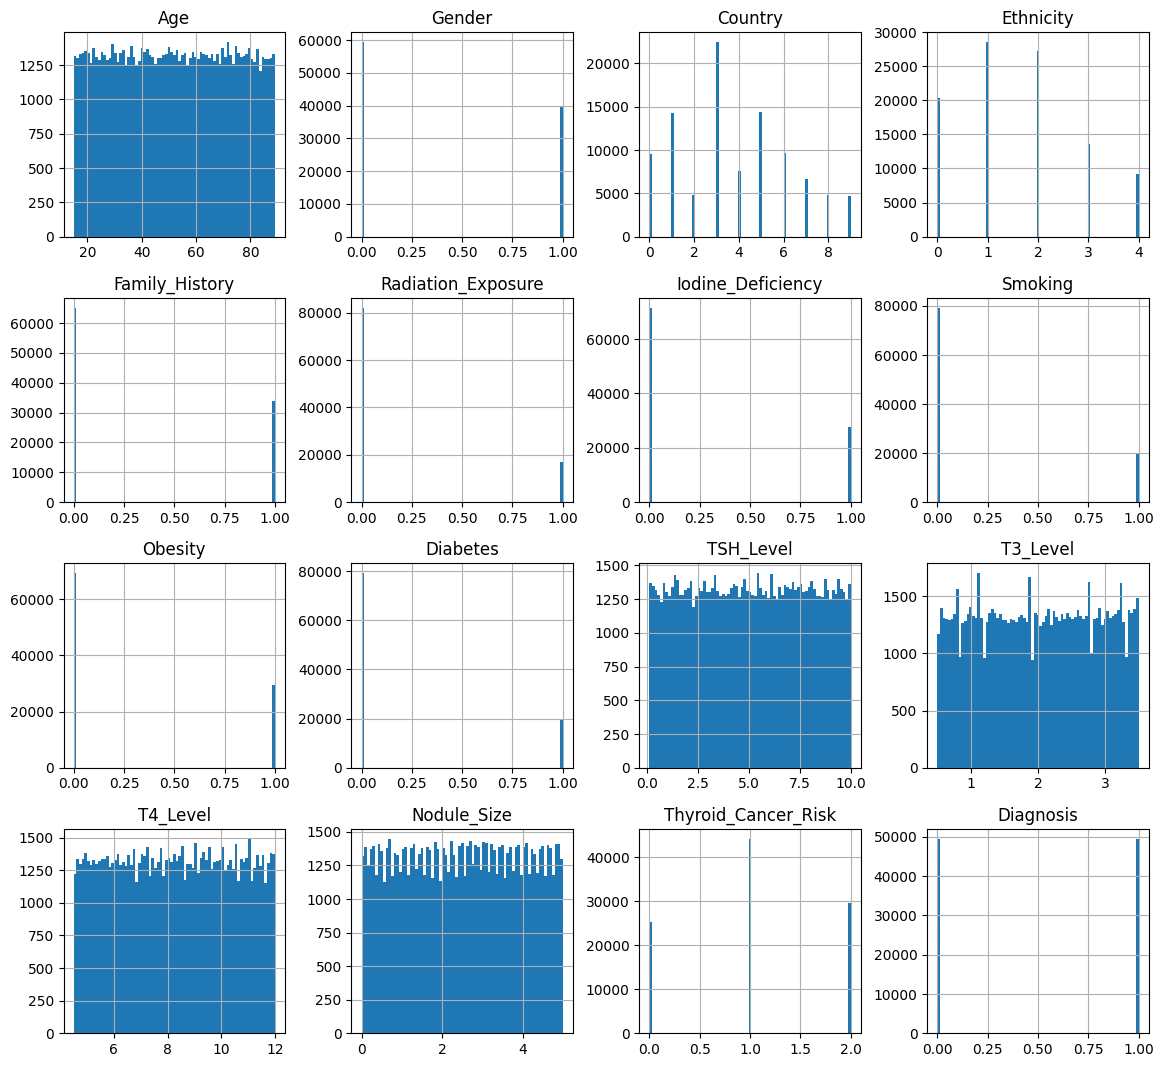

In [67]:
# scatter_matrix(dataset[attributes], alpha=0.9, figsize=(17, 15), diagonal='hist')

# Part 4: Data graphs

# Graphical: Preview dataset 1
import matplotlib.pyplot as plt

dataset.hist(bins=75, figsize=(14, 13))
plt.show()

# Graphical: Preview dataset 2
from pandas.plotting import scatter_matrix
attributes = []
for col in dataset.columns:
    attributes.append(col)
# scatter matrix takes a long time to run so commented out for now
# scatter_matrix(dataset[attributes], alpha=0.9, figsize=(17, 15), diagonal='kde')

In [68]:
# cell 8 - scatter plots:
# The scatterplots show the correlation between the 6 previously shown features
# some graphs indicate that there is a linear correlation between a number of features such as rel.humidity and humidity/ratio.
# A larger scatterplot of light, temperature and occupancy is also shown, indicating a linear correlation between the features.

TSH_Level per T3_Level
TSH_Level per T4_Level
TSH_Level per Nodule_Size
T3_Level per TSH_Level
T3_Level per T4_Level
T3_Level per Nodule_Size
T4_Level per TSH_Level
T4_Level per T3_Level
T4_Level per Nodule_Size
Nodule_Size per TSH_Level
Nodule_Size per T3_Level
Nodule_Size per T4_Level
['TSH_Level_per_T3_Level', 'TSH_Level_per_T4_Level', 'TSH_Level_per_Nodule_Size', 'T3_Level_per_TSH_Level', 'T3_Level_per_T4_Level', 'T3_Level_per_Nodule_Size', 'T4_Level_per_TSH_Level', 'T4_Level_per_T3_Level', 'T4_Level_per_Nodule_Size', 'Nodule_Size_per_TSH_Level', 'Nodule_Size_per_T3_Level', 'Nodule_Size_per_T4_Level'] 

['TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size'] 

TSH_Level by T3_Level
TSH_Level by T4_Level
TSH_Level by Nodule_Size
T3_Level by TSH_Level
T3_Level by T4_Level
T3_Level by Nodule_Size
T4_Level by TSH_Level
T4_Level by T3_Level
T4_Level by Nodule_Size
Nodule_Size by TSH_Level
Nodule_Size by T3_Level
Nodule_Size by T4_Level
'NaN' or 'inf' indices (row, column):  [(np.int64(528)

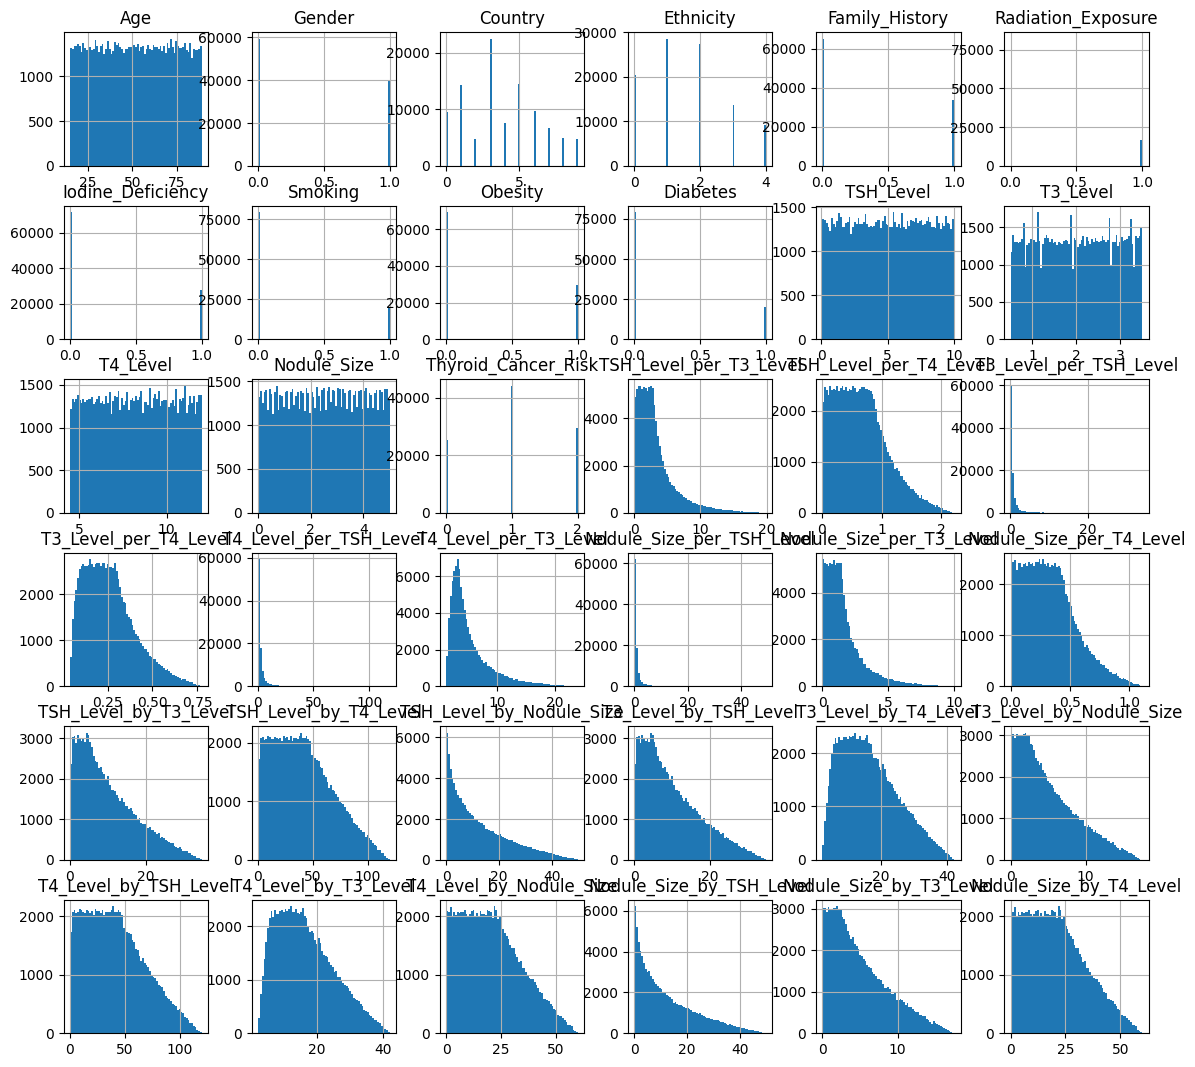

In [69]:
# Feature engineering steps

# Feature Identification ------
# Convert dataframe to float type
# Select input and target features (feats_X and trgt_y)

dataset = dataset.astype("float64")  # Convert pandas-dataframe to "float" type
feats_X = dataset.iloc[:, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]]
trgt_y = pd.DataFrame(dataset.iloc[:, 15])

# Feature Generation ------
# Create new features based on existing features (add new features to feats_X[])
# Check for 'NaN' or 'inf' values in features/inputs (Independent variables)
base_feats = ["TSH_Level", "T3_Level", "T4_Level", "Nodule_Size"]
new_feats = []
temp_df = feats_X.copy()
for col in dataset.columns:
    for i in range(len(base_feats)):
        if (col in base_feats and col != "Diagnosis" and col != base_feats[i]):
            # don't add inf or nan values
            # temp_df = abs(feats_X[col] / feats_X[base_feats[i]])
            # if not np.isinf(temp_df[f"{col}_per_{base_feats[i]}"][0]) and not np.isnan(temp_df[f"{col}_per_{base_feats[i]}"][0]):
            new_feats.append(f"{col}_per_{base_feats[i]}")
            print(f"{col} per {base_feats[i]}")
            feats_X[f"{col}_per_{base_feats[i]}"] = abs(feats_X[col] / feats_X[base_feats[i]])

print(new_feats, "\n")
print(base_feats, "\n")

for col in dataset.columns:
    for i in range(len(base_feats)):
        if (col in base_feats and col != "Diagnosis" and col != base_feats[i]):
            # don't add inf or nan values
            # temp_df = abs(feats_X[col] / feats_X[base_feats[i]])
            # if not np.isinf(temp_df[f"{col}_per_{base_feats[i]}"][0]) and not np.isnan(temp_df[f"{col}_per_{base_feats[i]}"][0]):
            new_feats.append(f"{col}_by_{base_feats[i]}")
            print(f"{col} by {base_feats[i]}")
            feats_X[f"{col}_by_{base_feats[i]}"] = feats_X[col] * feats_X[base_feats[i]]
            
indices = np.where(np.isinf(feats_X) | np.isnan(feats_X))
print("'NaN' or 'inf' indices (row, column): ", list(zip(*indices)))

# remove inf and nan values from dataframe
feats_X = feats_X.dropna()
feats_X = feats_X.dropna(axis=1)
for col in feats_X.columns:
    if feats_X[col].isnull().values.any() or np.isinf(feats_X[col]).any():
        feats_X = feats_X.drop(col, axis=1)

indices = np.where(np.isinf(feats_X) | np.isnan(feats_X))
print("'NaN' or 'inf' indices (row, column): ", list(zip(*indices)))

feats_X.hist(bins=75, figsize=(14, 13))
plt.show()


   Gender  Country  Ethnicity  Family_History  Radiation_Exposure  Iodine_Deficiency  Obesity  Thyroid_Cancer_Risk  TSH_Level_by_T4_Level  T3_Level_by_T4_Level  T4_Level_by_TSH_Level  T4_Level_by_T3_Level
0     1.0      6.0        2.0             0.0                 0.0                0.0      1.0                  1.0                49.6584               23.5950                49.6584               23.5950
1     1.0      6.0        2.0             1.0                 0.0                0.0      1.0                  1.0                 9.0774               37.0845                 9.0774               37.0845
2     0.0      1.0        0.0             0.0                 0.0                0.0      0.0                  1.0                17.9064               26.3622                17.9064               26.3622
3     1.0      0.0        4.0             1.0                 1.0                1.0      0.0                  1.0                 8.7205               14.9265                 8.72

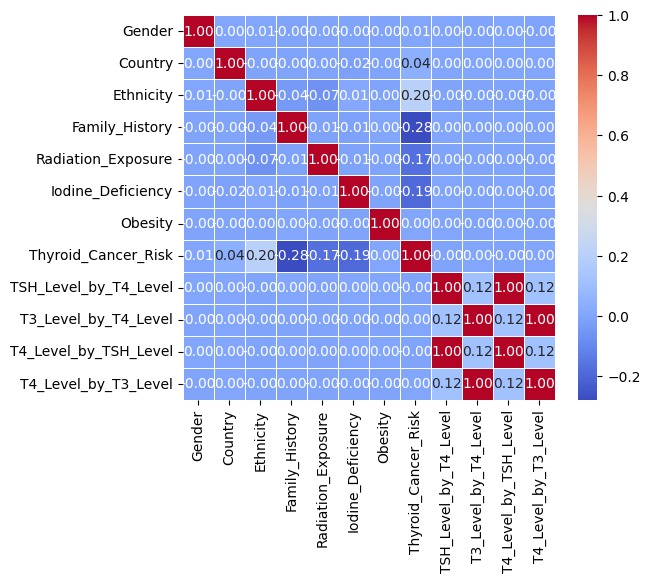

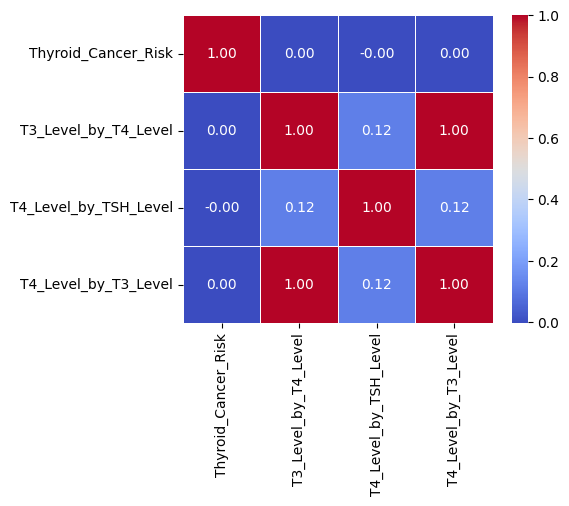

In [ ]:
# Feature Selection ------


  # Determine if we use linear or non-linear function for KBest score_func
    # Try both linear and non-linear and choose the one with better results
# Use a correlation matrix to determine which features to keep or remove
  # Determine if we use linear or non-linear function for feats_X.corr()
    # Try both linear and non-linear and choose the one with better results
# Show correlation matrix plot and take out bad or redundant features
# Repeat until we have only good features

import seaborn as sbn
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# drop_feats = [0, 1, 2, 3, 4, 8, 9, 14]
drop_feats = ["Age", "Gender", "Country", "Ethnicity", "Family_History",
              "Obesity", "Diabetes", "Thyroid_Cancer_Risk",
              "Radiation_Exposure", "Iodine_Deficiency", "Smoking"]

feats_X = feats_X.drop(columns=drop_feats)

print(feats_X.info())

# Use SelectKBest to select top k features
# Use a classification function in KBest
for t in range(trgt_y.shape[1]):
  KBest = SelectKBest(score_func=mutual_info_classif, k=14)  # Linear(f_regression|f_classif) to target; Nonlinear(mutual_info_regression|mutual_info_classif) to target
  output = KBest.fit_transform(feats_X, trgt_y.iloc[:,t])  # Fits to data & transform/reduce it to the selected features
  top_feats_X = pd.DataFrame(output, columns=KBest.get_feature_names_out())  # Transfrom numpy-array 2 pandas-dataframe
  print(top_feats_X.head(), "\n")

# AVOID Multi-Collinearity/Redundancy: features(Independent/Input) --high +/-ve correlation--> features(Independent/Input)
useful_feats_X = top_feats_X.loc[:, :]
useful_feats_corr = useful_feats_X.corr('kendall')  # Linear(pearson) to target; Nonlinear(kendall|spearman) to target
plt.figure(figsize=(10, 8))
sbn.heatmap(useful_feats_corr, annot=True, linewidths=0.5, fmt='.2f', cmap='coolwarm')  # cmap='coolwarm|RdBu|BrBG|PRGn|viridis|Blues|Greens|Oranges|rocket|tab10|Set1|Pastel1|Accent'
plt.show()  # figsize(inch, inch); (-ve corr., 0, +ve corr.)

feats_to_not_use = ["Nodule_Size_by_TSH_Level", "Nodule_Size_by_T3_Level",
                    "T4_Level_by_T3_Level", "T4_Level_by_TSH_Level", "TSH_Level",
                    "T4_Level", "T3_Level", "Nodule_Size"]
temp_df = top_feats_X.copy()
temp_df = temp_df.drop(columns=feats_to_not_use)
# AVOID Multi-Collinearity/Redundancy: features(Independent/Input) --high +/-ve correlation--> features(Independent/Input)
useful_feats_X = temp_df.copy()
useful_feats_corr = useful_feats_X.corr('kendall')  # Linear(pearson) to target; Nonlinear(kendall|spearman) to target
plt.figure(figsize=(10, 8))
sbn.heatmap(useful_feats_corr, annot=True, linewidths=0.5, fmt='.2f', cmap='coolwarm')  # cmap='coolwarm|RdBu|BrBG|PRGn|viridis|Blues|Greens|Oranges|rocket|tab10|Set1|Pastel1|Accent'
plt.show()  # figsize(inch, inch); (-ve corr., 0, +ve corr.)

In [71]:
# Training and Test Sets ----
# Import Sklearn for model selection and Stratified method for training (Shuffle Split reccomended)
# Print shape of selected feats and target
# Use StratifiedShuffleSplit to split data for training and testing
# Print shape of outputs to evaluate proper allocation

# Feature Transformation ----
# Scale/normalize features ("skewness/unsymmetric" dataset)
# Use Z-Score Normalization for features
# Use QuantileTransformer() transforms for highly skewed features (turns into normal distrebution)
# Apply to both features and target
# Print histogram to varify new distribution

# Algorithm Selection ----
# Import possible ML models
# Select ML model to test/use
# Create if/then path to automatically import model and apply hyperparameters


In [72]:
#Comments/Steps --

  # TRAINING: K-Fold Cross-Validation. Fit algorithm(ML) to data(Training) --
    #import
    #cross-validation prediction
      #splilt data into 3 folds
      #train model on 2 folds
      #test on remaining
      #repeat with all combos
    #convert predictions into dataframe
    #extract lables as NumPy array

  # Evaluate model's performance. Overfitting(Train ERR << Test ERR); Underfitting(Train ERR >> Test ERR) --
    #compute Accuraccy
    #compute precision, recall, f1-score
    #compute mcc
    #fit model using all training data
    #compute roc

  # Training/Validation Metrics --
    #print results

  # TESTING/GENERALIZATION: Make Predictions for 'y-component' wrt. data(Test) --
    #train model using entire dataset
    #make predictions
    #prepare true labels

  # Evaluate model's performance. Overfitting(Train ERR << Test ERR); Underfitting(Train ERR >> Test ERR).
    #compute
    #predict probabilities of classes

  # Testing Metrics
    #print results

  # Confusion Matrix
    #import confusion matrix
    #compare actual and predicted labels
    #make heatmap

